In [3]:
import numpy as np
import matplotlib.pyplot as plt



def q(omega, taum):
    return np.sqrt(1.0 + 1j * omega * taum)

def lambda_cable(d, Rm, Ri):
    return np.sqrt(d * Rm / (4 * Ri))

def G_infty(d, Rm, Ri):
    lam = lambda_cable(d, Rm, Ri)
    return np.pi * d**2 / (4 * lam * Ri)

def Y_soma(omega, ds, Rm, taum):
    return np.pi * ds**2 * q(omega, taum)**2 / Rm

def Y_dendrite(omega, d, l, Ri, Rm, taum):
    lam = lambda_cable(d, Rm, Ri)
    return G_infty(d, Rm, Ri) * q(omega, taum) * np.tanh(q(omega, taum) * l / lam)

def Tp_general(omega, ds, Rm, taum, d, l, theta, Ri):

    qv = q(omega, taum)

    numerator = 0.0 + 0.0j
    for di, li, th in zip(d, l, theta):
        lam = lambda_cable(di, Rm, Ri)
        numerator += lam * G_infty(di, Rm, Ri) * (
            1.0 - 1.0 / np.cosh(qv * li / lam)
        ) * np.cos(th)

    Ytot = Y_soma(omega, ds, Rm, taum)
    for di, li in zip(d, l):
        Ytot += Y_dendrite(omega, di, li, Ri, Rm, taum)

    return numerator / Ytot


In [4]:
# Parameters (same as notebook)
ds   = 10e-6
Rm   = 3.0
Ri   = 1.5
Cm   = 0.01
taum = Rm * Cm

f = np.logspace(0, 3, 800)
omega = 2 * np.pi * f




In [6]:
cell_models = {

    "Ball + stick": dict(
        color="black",
        d=[0.6e-6],
        l=[800e-6],
        theta=[0.0]
    ),

    "Pyramidal (up + down)": dict(
        color="green",
        d=[0.6e-6, 0.6e-6],
        l=[800e-6, 250e-6],
        theta=[0.0, np.pi]
    ),

    "Pyramidal (up + side)": dict(
        color="blue",
        d=[0.6e-6, 0.6e-6],
        l=[800e-6, 250e-6],
        theta=[0.0, np.pi/2]
    ),

    "Interneuron": dict(
        color="red",
        d=[0.6e-6, 0.6e-6, 0.6e-6, 0.6e-6],
        l=[400e-6, 400e-6, 300e-6, 300e-6],
        theta=[-np.pi/4, np.pi/4, -3*np.pi/4, 3*np.pi/4]
    )
}

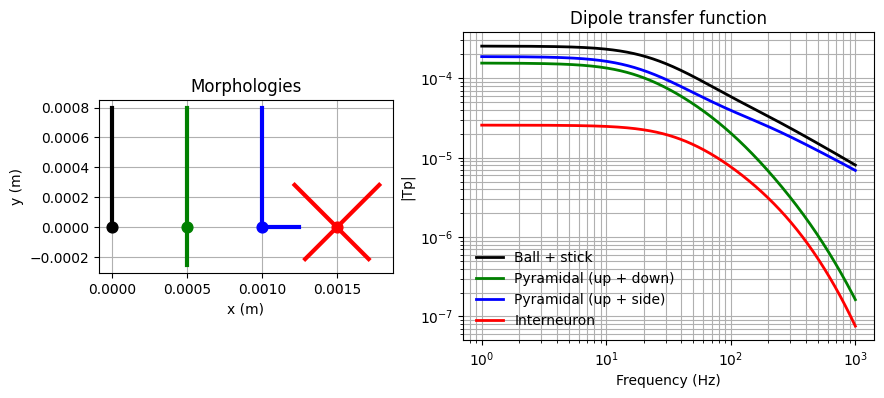

In [7]:
fig, (ax_morph, ax_tf) = plt.subplots(
    1, 2, figsize=(10, 4),
    gridspec_kw=dict(width_ratios=[1, 1.4])
)

x_offsets = {
    "Ball + stick": 0.0,
    "Pyramidal (up + down)": 0.5e-3,
    "Pyramidal (up + side)": 1.0e-3,
    "Interneuron": 1.5e-3,
}

for name, cell in cell_models.items():
    x0 = x_offsets[name]
    y0 = 0.0
    col = cell["color"]

    # soma
    ax_morph.scatter(x0, y0, s=60, color=col, zorder=3)

    # sticks
    for li, th in zip(cell["l"], cell["theta"]):
        dx = li * np.sin(th)
        dy = li * np.cos(th)

        ax_morph.plot(
            [x0, x0 + dx],
            [y0, y0 + dy],
            lw=3,
            color=col
        )

ax_morph.set_aspect("equal")
ax_morph.set_xlabel("x (m)")
ax_morph.set_ylabel("y (m)")
ax_morph.set_title("Morphologies")
ax_morph.grid(True)


for name, cell in cell_models.items():
    Tp = np.array([
        Tp_general(
            w, ds, Rm, taum,
            cell["d"], cell["l"], cell["theta"], Ri
        )
        for w in omega
    ])

    ax_tf.loglog(
        f, np.abs(Tp),
        color=cell["color"],
        label=name,
        lw=2
    )

ax_tf.set_xlabel("Frequency (Hz)")
ax_tf.set_ylabel("|Tp|")
ax_tf.set_title("Dipole transfer function")
ax_tf.grid(True, which="both")
ax_tf.legend(frameon=False)


In [19]:
from neuron import h
import LFPy
import numpy as np

def return_ball_and_N_sticks_cell(
    tstop,
    dt,
    d,
    l,
    theta,
    soma_diam=20.0,
    soma_len=20.0,
    nseg_per_100um=20
):
    """
    Ball-and-N-sticks NEURON/LFPy cell

    d     : list of diameters (meters)
    l     : list of lengths   (meters)
    theta : list of angles (rad, 0 = up)
    """

    assert len(d) == len(l) == len(theta)

    N = len(d)

    # Convert to microns (NEURON units)
    d_um = np.array(d) * 1e6
    l_um = np.array(l) * 1e6

    h("forall delete_section()")

    hoc = f"""
    create soma[1], dend[{N}]

    objref all
    
    all = new SectionList()
    soma[0] all.append()

    proc topol() {{
        for i = 0, {N-1} {{
            connect dend[i](0), soma[0](0.5)
            dend[i] all.append()
        }}
        
    }}

    proc basic_shape() {{
        soma[0] {{
            pt3dclear()
            pt3dadd(0, 0, {-soma_len/2}, {soma_diam})
            pt3dadd(0, 0, { soma_len/2}, {soma_diam})
        }}

        """
    for i in range(N):
        dx = l_um[i] * np.sin(theta[i])
        dy = l_um[i] * np.cos(theta[i])

        hoc += f"""
        dend[{i}] {{
            pt3dclear()
            pt3dadd(0, 0, {soma_len/2}, {d_um[i]})
            pt3dadd({dx}, {dy}, {soma_len/2}, {d_um[i]})
        }}
        """

    hoc += """
    }

    proc geom_nseg() {
        soma[0] { nseg = 1 }
        forsec dend {
            nseg = int(L/100 * %d) + 1
        }
    }

    proc biophys() {
        forall {
            Ra = 150.
            cm = 1.
            insert pas
            g_pas = 1.0 / 30000.
            e_pas = -70.
        }
    }

    proc celldef() {
        topol()
        basic_shape()
        geom_nseg()
        biophys()
    }

    celldef()
    """ % nseg_per_100um

    h(hoc)

    cell = LFPy.Cell(
        morphology=h.all,
        delete_sections=False,
        v_init=-70.,
        passive=False,
        nsegs_method=None,
        dt=dt,
        tstart=-100.,
        tstop=tstop,
        pt3d=True,
    )

    return cell

In [20]:
cells = {}

for name, celldef in cell_models.items():
    cell = return_ball_and_N_sticks_cell(
        tstop=100.,
        dt=2**-4,
        d=celldef["d"],
        l=celldef["l"],
        theta=celldef["theta"]
    )
    cells[name] = cell

NEURON: syntax error
 near line 35
         forsec dend {
                     ^
NEURON: syntax error
 near line 41
         forsec dend {
                     ^
NEURON: syntax error
 near line 41
         forsec dend {
                     ^
NEURON: syntax error
 near line 53
         forsec dend {
                     ^
